# **Importing Libraries**

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **BTC Stocks & EMA Calculation**

In [35]:
start_date = '2018-01-01'
end_date = '2022-12-01'

btc = yf.download('BTC-USD', start=start_date, end=end_date, interval='1d')
btc.columns = btc.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


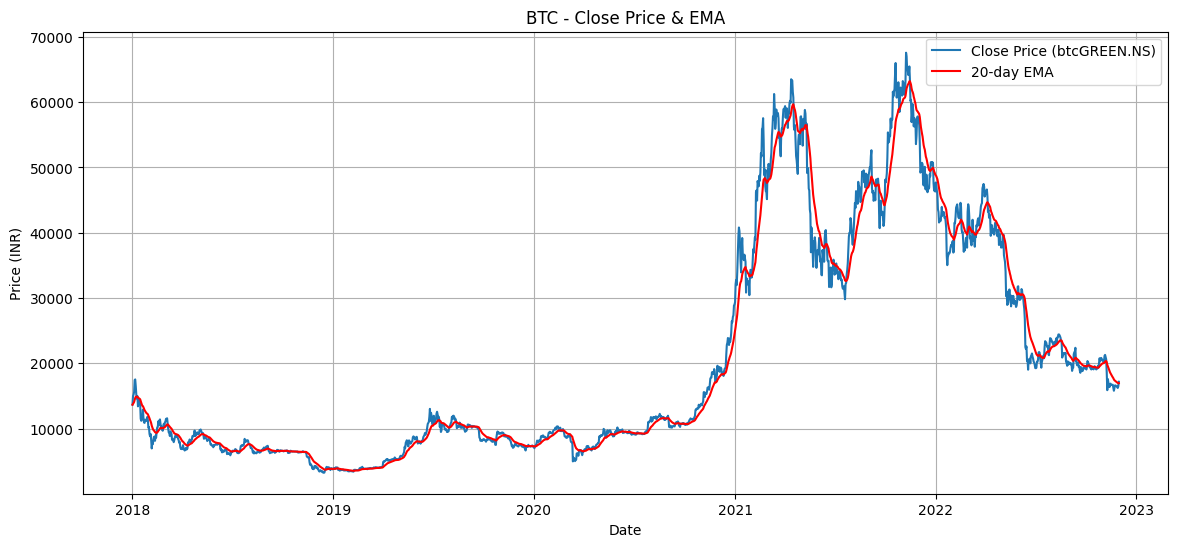

In [36]:
btc['EMA'] = btc['Close'].ewm(span=20, adjust=False).mean()

#Plotting
plt.figure(figsize=(14, 6))
plt.plot(btc.index, btc['Close'], label='Close Price (btcGREEN.NS)')
plt.plot(btc.index, btc['EMA'], label='20-day EMA', color='red')
plt.title('BTC - Close Price & EMA')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# **Using ATR Breakout Strategy**

Upper Band : EMA + k*ATR

Lower Band : EMA - k*ATR

Here, Using k = 1.2

* Buy Signal : Price > Upper Band
* Sell Signal : Price < Lower Band

In [37]:
high_low_a = btc['High'] - btc['Low']
high_close_prev_a = abs(btc['High'] - btc['Close'].shift(1))
low_close_prev_a = abs(btc['Low'] - btc['Close'].shift(1))

btc['True_Range'] = pd.concat([high_low_a, high_close_prev_a, low_close_prev_a], axis=1).max(axis=1)

btc['ATR'] = btc['True_Range'].ewm(span=14, adjust=False).mean()

In [38]:
k = 1.2
btc['Upper_Band'] = btc['EMA'] + k * btc['ATR']
btc['Lower_Band'] = btc['EMA'] - k * btc['ATR']

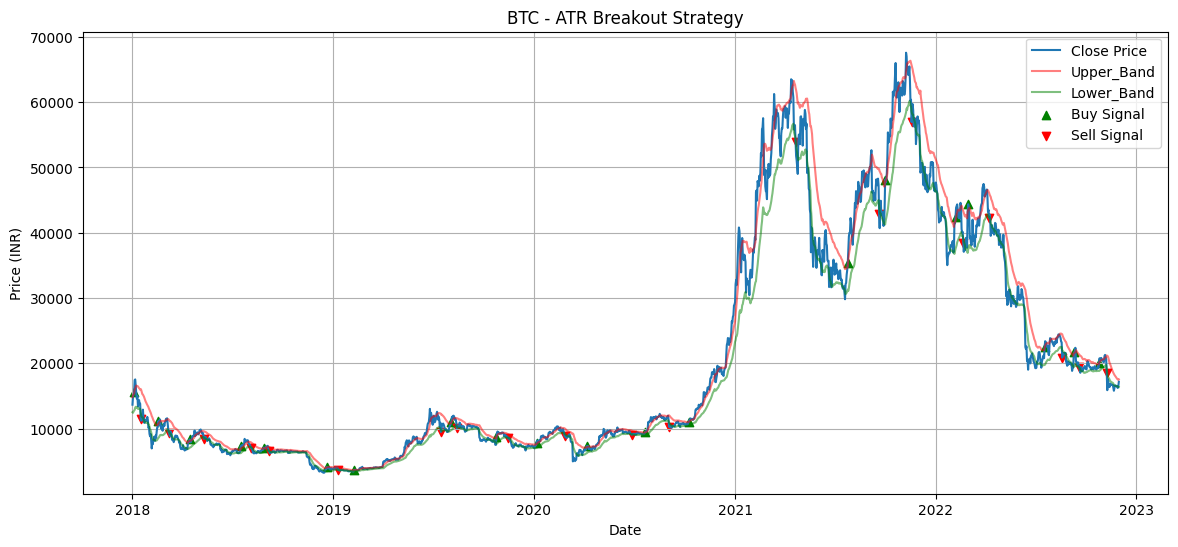

In [39]:
btc['Signal'] = 0

btc.loc[(btc['Close'] > btc['Upper_Band']), 'Signal'] = 1
btc.loc[(btc['Close'] < btc['Lower_Band']), 'Signal'] = -1

last_signal = 0
for i in range(len(btc)):
    current = btc.loc[btc.index[i], 'Signal']
    if current != 0:
        if current == last_signal:
            btc.loc[btc.index[i], 'Signal'] = 0
        else:
            last_signal = current

# Plotting
plt.figure(figsize=(14, 6))
plt.plot(btc.index, btc['Close'], label='Close Price')
plt.plot(btc.index, btc['Upper_Band'], label='Upper_Band', color='red',alpha=0.5)
plt.plot(btc.index, btc['Lower_Band'], label='Lower_Band', color='green',alpha =0.5)
plt.scatter(btc[btc['Signal'] == 1].index, btc[btc['Signal'] == 1]['Close'], label='Buy Signal', marker='^', color='green')
plt.scatter(btc[btc['Signal'] == -1].index, btc[btc['Signal'] == -1]['Close'], label='Sell Signal', marker='v', color='red')
plt.title('BTC - ATR Breakout Strategy')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend()
plt.grid(True)
plt.show()

# **Backtesting**

For risk management, I uses trailing stop loss

Using capital with stop loss trailing

In [40]:
# def capital(data, trade_index):
#     capt = [1000000]
#     k = 0
#     nia = 1000000
#     quantity = 0

#     for i in range(len(data)-1):
#         if k < len(trade_index) and i == trade_index[k]:

#             if data['Signal_1'].iloc[i] == 1:
#                 quantity = int(nia / data["Close"].iloc[i])
#                 nia -= quantity * data["Close"].iloc[i]
#                 capt.append(nia)
#             elif data['Signal_1'].iloc[i] == -1:
#                 nia += quantity * data["Close"].iloc[i]
#                 quantity = 0
#                 capt.append(nia)
#             k += 1
#         else:

#             capt.append(nia + quantity * data["Close"].iloc[i])

#     data['Capital'] = capt
#     return data
def capital_with_trailing_stoploss(data, trade_index, signal_col, stop_loss_pct, initial_capital=1_000_000):
    capital = initial_capital
    quantity = 0
    position = None
    entry_price = 0
    max_price = 0
    min_price = 0

    capt = []
    shares_list = []

    opening_trade_idx = []
    closing_trade_idx = []
    entry_date = []
    exit_date = []
    type_of_trade = []
    returns = []
    trade_quantity = []

    k = 0

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        signal = data[signal_col].iloc[i]

        if k < len(trade_index) and i == trade_index[k]:
            if signal == 1 and position is None:
                quantity = int(capital / price)
                capital -= quantity * price
                entry_price = price
                max_price = price
                position = 'long'

                opening_trade_idx.append(i)
                entry_date.append(data.index[i])
                type_of_trade.append('long')
                trade_quantity.append(quantity)

            elif signal == -1 and position is None:
                quantity = int(capital / price)
                capital += quantity * price
                entry_price = price
                min_price = price
                position = 'short'

                opening_trade_idx.append(i)
                entry_date.append(data.index[i])
                type_of_trade.append('short')
                trade_quantity.append(quantity)

            elif signal == -1 and position == 'long':
                capital += quantity * price
                position = None

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - entry_price) * 100) / entry_price
                returns.append(ret)

                quantity = 0

            elif signal == 1 and position == 'short':
                capital -= quantity * price
                position = None

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((entry_price - price) * 100) / entry_price
                returns.append(ret)

                quantity = 0

            k += 1

        # Trailing stop-loss
        if position == 'long':
            max_price = max(max_price, price)
            if price < max_price * (1 - stop_loss_pct):
                capital += quantity * price
                position = None

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((price - entry_price) * 100) / entry_price
                returns.append(ret)

                quantity = 0

        elif position == 'short':
            min_price = min(min_price, price)
            if price > min_price * (1 + stop_loss_pct):
                capital -= quantity * price
                position = None

                closing_trade_idx.append(i)
                exit_date.append(data.index[i])
                ret = ((entry_price - price) * 100) / entry_price
                returns.append(ret)

                quantity = 0

        # Daily portfolio value
        if position == 'long':
            portfolio_value = capital + quantity * price
        elif position == 'short':
            portfolio_value = capital - quantity * price
        else:
            portfolio_value = capital

        capt.append(portfolio_value)
        shares_list.append(quantity)

    # end position square-off
    if position == 'long':
        final_price = data['Close'].iloc[-1]
        capital += quantity * final_price
        closing_trade_idx.append(len(data) - 1)
        exit_date.append(data.index[-1])
        ret = ((final_price - entry_price) * 100) / entry_price
        returns.append(ret)

    elif position == 'short':
        final_price = data['Close'].iloc[-1]
        capital -= quantity * final_price
        closing_trade_idx.append(len(data) - 1)
        exit_date.append(data.index[-1])
        ret = ((entry_price - final_price) * 100) / entry_price
        returns.append(ret)

    if len(capt) < len(data):
        last_val = capt[-1]
        capt += [last_val] * (len(data) - len(capt))
        shares_list += [0] * (len(data) - len(shares_list))

    daily_df = pd.DataFrame({
        'Portfolio Value': capt,
        'No. of Stock': shares_list
    }, index=data.index)

    daily_df['Profit from Initial Capital (%)'] = (daily_df['Portfolio Value'] - initial_capital) * 100 / initial_capital
    daily_df['Daily Returns (%)'] = daily_df['Portfolio Value'].pct_change() * 100

    trade_wise_df = pd.DataFrame({
        'Entry Index': opening_trade_idx,
        'Exit Index': closing_trade_idx,
        'Entry Date': entry_date,
        'Exit Date': exit_date,
        'Type of Trade': type_of_trade,
        'No of stock traded': trade_quantity,
        'Return for trade in %': returns,
        'Trade Duration': [e - s for s, e in zip(opening_trade_idx, closing_trade_idx)]
    })

    return trade_wise_df, daily_df


In [41]:
trade_index = []
for i in range(len(btc)):
    if btc['Signal'].iloc[i] == 1 or btc['Signal'].iloc[i] == -1:
        trade_index.append(i)

btc_trade,btc_det = capital_with_trailing_stoploss(btc, trade_index, "Signal", 0.15)
btc_det

,Portfolio Value,No. of Stock,Profit from Initial Capital (%),Daily Returns (%)
Date,,,,
2018-01-01,1.000000e+06,0,0.000000,NaN
2018-01-02,1.000000e+06,0,0.000000,0.000000
2018-01-03,1.000000e+06,0,0.000000,0.000000
2018-01-04,1.000000e+06,64,0.000000,0.000000
2018-01-05,1.117139e+06,64,11.713919,11.713919
...,...,...,...,...
2022-11-26,9.530959e+06,0,853.095942,0.000000
2022-11-27,9.530959e+06,0,853.095942,0.000000
2022-11-28,9.530959e+06,0,853.095942,0.000000


Calculating all performance metrics

In [42]:
def print_metrics(trade_wise_df, daily_df, benchmark_close):
    benchmark_return = ((benchmark_close.iloc[-1] - benchmark_close.iloc[0]) * 100) / benchmark_close.iloc[0]
    gross_profit = daily_df["Profit from Initial Capital (%)"].iloc[-1]
    max_holding_time = trade_wise_df['Trade Duration'].max()
    avg_holding_time = trade_wise_df['Trade Duration'].mean()

    total_trades = len(trade_wise_df)
    winning_trades = (trade_wise_df['Return for trade in %'] > 0).sum()
    losing_trades = (trade_wise_df['Return for trade in %'] <= 0).sum()

    total_long_trades = (trade_wise_df['Type of Trade'] == 'long').sum()
    total_short_trades = (trade_wise_df['Type of Trade'] == 'short').sum()

    portfolio = daily_df['Portfolio Value']
    roll_max = portfolio.cummax()
    drawdown = (roll_max - portfolio)* 100 / roll_max
    max_drawdown = drawdown.max()
    avg_drawdown = drawdown.mean()

    daily_returns = daily_df['Daily Returns (%)'] / 100
    sharpe_daily = daily_returns.mean() / daily_returns.std()
    sharpe_annualized = sharpe_daily * np.sqrt(252)

    downside_returns = daily_returns[daily_returns < 0]
    sortino_ratio = daily_returns.mean() / downside_returns.std()
    sortino_annualized = sortino_ratio * np.sqrt(252)

    # Print all metrics
    print("Benchmark Return: {:.2f} %".format(benchmark_return))
    print("Gross Profit: {:.2f} %".format(gross_profit))
    print("Total Trades Executed: {}".format(total_trades))
    print("Win Rate: {:.2f} %".format((winning_trades / total_trades) * 100))
    print("Losing Trades: {}".format(losing_trades))
    print("Total Long Trades: {}".format(total_long_trades))
    print("Total Short Trades: {}".format(total_short_trades))
    print("Average Drawdown: {:.2f} %".format(avg_drawdown))
    print("Maximum Drawdown: {:.2f} %".format(max_drawdown))
    print("Sharpe Ratio (Daily): {:.2f}".format(sharpe_daily))
    print("Sharpe Ratio (Annualized): {:.2f}".format(sharpe_annualized))
    print("Sortino Ratio (Daily): {:.2f}".format(sortino_ratio))
    print("Sortino Ratio (Annualized): {:.2f}".format(sortino_annualized))
    print("Average Holding Time: {}".format(avg_holding_time))
    print("Maximum Holding Time: {}".format(max_holding_time))


In [43]:
print_metrics(btc_trade, btc_det, btc['Close'])

Benchmark Return: 25.71 %
Gross Profit: 853.10 %
Total Trades Executed: 24
Win Rate: 45.83 %
Losing Trades: 13
Total Long Trades: 17
Total Short Trades: 7
Average Drawdown: 19.99 %
Maximum Drawdown: 44.08 %
Sharpe Ratio (Daily): 0.06
Sharpe Ratio (Annualized): 0.99
Sortino Ratio (Daily): 0.06
Sortino Ratio (Annualized): 1.03
Average Holding Time: 36.375
Maximum Holding Time: 142
